In [2]:
!git clone https://github.com/beta21s/Face-recognition.git

Cloning into 'Face-recognition'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 48 (delta 9), reused 42 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 103.93 MiB | 19.66 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [4]:
# Di chuyển đến thư mục chứa file requirements.txt
!cd /content/Face-recognition

# Cài thư viện
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.9 MB/s eta 0:00:00


In [14]:
from architecture import *
import os
import cv2
import mtcnn
import pickle
import numpy as np
from sklearn.preprocessing import Normalizer

# =========================
# CONFIG
# =========================
face_data = 'Faces/'                 # Thư mục chứa ảnh khuôn mặt
required_shape = (160, 160)
weights_path = 'facenet_keras_weights.h5'
encodings_path = 'encodings/encodings.pkl'

# =========================
# LOAD MODEL
# =========================
face_encoder = InceptionResNetV2()
face_encoder.load_weights(weights_path)

face_detector = mtcnn.MTCNN()
l2_normalizer = Normalizer('l2')

encoding_dict = {}

# =========================
# FACENET NORMALIZATION
# =========================
def preprocess_face(face):
    face = cv2.resize(face, required_shape)
    face = face.astype('float32')
    face = (face - 127.5) / 128.0
    return face

# =========================
# CREATE ENCODINGS
# =========================
for person_name in os.listdir(face_data):
    person_dir = os.path.join(face_data, person_name)

    if not os.path.isdir(person_dir):
        continue

    person_encodes = []

    for image_name in os.listdir(person_dir):
        image_path = os.path.join(person_dir, image_name)

        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        results = face_detector.detect_faces(img_rgb)
        if len(results) == 0:
            continue

        x, y, w, h = results[0]['box']
        x, y = abs(x), abs(y)
        face = img_rgb[y:y+h, x:x+w]

        if face.size == 0:
            continue

        face = preprocess_face(face)
        face = np.expand_dims(face, axis=0)

        embedding = face_encoder.predict(face, verbose=0)[0]
        person_encodes.append(embedding)

    if len(person_encodes) == 0:
        continue

    person_encodes = np.asarray(person_encodes)
    mean_encode = np.mean(person_encodes, axis=0)
    mean_encode = l2_normalizer.transform(mean_encode.reshape(1, -1))[0]

    encoding_dict[person_name] = mean_encode
    print(f"[INFO] Encoded: {person_name}")

# =========================
# SAVE ENCODINGS
# =========================
os.makedirs(os.path.dirname(encodings_path), exist_ok=True)

with open(encodings_path, 'wb') as f:
    pickle.dump(encoding_dict, f)

print("✅ Encoding completed. Saved to:", encodings_path)


[INFO] Encoded: Kamal
[INFO] Encoded: Nitesh
[INFO] Encoded: Rajan
[INFO] Encoded: Pawan
✅ Encoding completed. Saved to: encodings/encodings.pkl


In [10]:
import tensorflow as tf
print(f"Current TensorFlow version: {tf.__version__}")

Current TensorFlow version: 2.19.0


In [11]:
# Install a specific TensorFlow version that is known to work with this library
!pip install tensorflow==2.10.0

# Restart runtime after installation
# You will need to manually restart the runtime after this cell finishes execution
# (Runtime -> Restart runtime)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.10.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.10.0


/tmp/ipython-input-622668222.py:15: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client()


✅ MQTT: OPEN


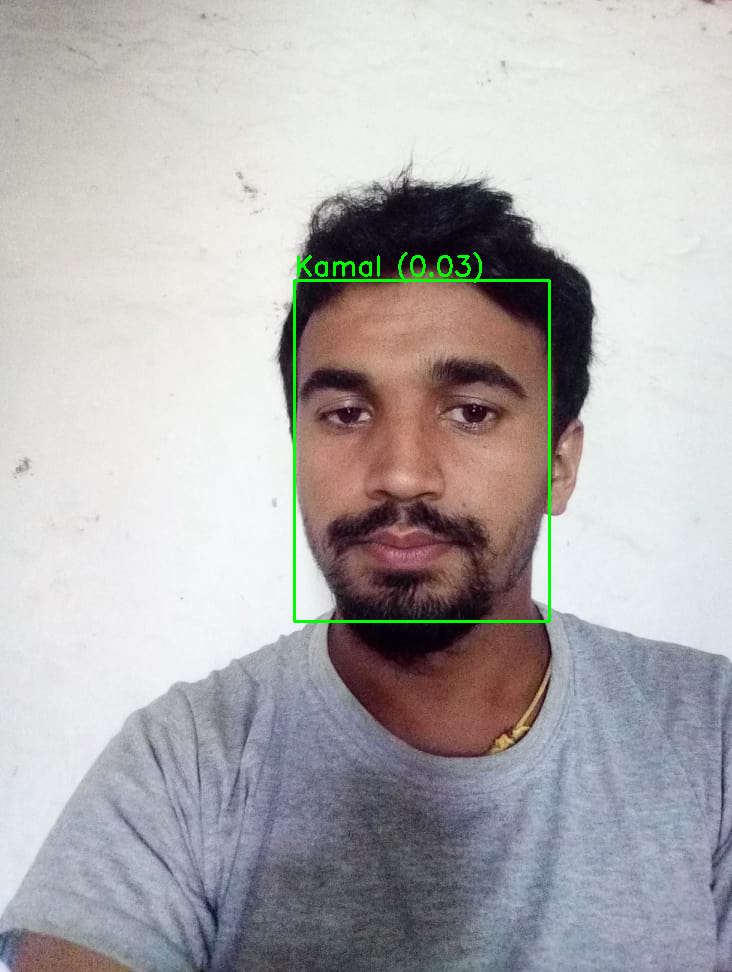

In [20]:
!pip install paho-mqtt

import cv2
import numpy as np
import mtcnn
import pickle
from architecture import *
from scipy.spatial.distance import cosine
from sklearn.preprocessing import Normalizer
import paho.mqtt.client as mqtt

# =========================
# MQTT
# =========================
mqtt_client = mqtt.Client()
mqtt_client.connect("broker.hivemq.com", 1883, 60)

# =========================
# CONFIG
# =========================
confidence_t = 0.95
recognition_t = 0.5
required_size = (160, 160)

# =========================
# LOAD MODEL
# =========================
face_encoder = InceptionResNetV2()
face_encoder.load_weights("facenet_keras_weights.h5")

face_detector = mtcnn.MTCNN()
l2_normalizer = Normalizer('l2')

# =========================
# LOAD ENCODINGS
# =========================
with open("encodings/encodings.pkl", "rb") as f:
    encoding_dict = pickle.load(f)

# =========================
# FACENET PREPROCESS
# =========================
def preprocess_face(face):
    face = cv2.resize(face, required_size)
    face = face.astype("float32")
    face = (face - 127.5) / 128.0
    return face

# =========================
# GET FACE
# =========================
def get_face(img, box):
    x, y, w, h = box
    x, y = abs(x), abs(y)
    return img[y:y+h, x:x+w], (x, y), (x+w, y+h)

# =========================
# FACE RECOGNITION
# =========================
def recognize(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = face_detector.detect_faces(img_rgb)

    recognized_name = "unknown"

    for res in results:
        if res['confidence'] < confidence_t:
            continue

        face, pt1, pt2 = get_face(img_rgb, res['box'])
        if face.size == 0:
            continue

        face = preprocess_face(face)
        face = np.expand_dims(face, axis=0)

        encode = face_encoder.predict(face, verbose=0)[0]
        encode = l2_normalizer.transform(encode.reshape(1, -1))[0]

        min_dist = 1.0

        for db_name, db_encode in encoding_dict.items():
            dist = cosine(db_encode, encode)
            if dist < recognition_t and dist < min_dist:
                recognized_name = db_name
                min_dist = dist

        # Draw
        if recognized_name == "unknown":
            color = (0, 0, 255)
            label = "UNKNOWN"
        else:
            color = (0, 255, 0)
            label = f"{recognized_name} ({min_dist:.2f})"

        cv2.rectangle(img, pt1, pt2, color, 2)
        cv2.putText(img, label, (pt1[0], pt1[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    return img, recognized_name

# =========================
# MAIN
# =========================
image_path = "/content/Face-recognition/Faces/Kamal/4.jpg"
image = cv2.imread(image_path)

if image is None:
    print("❌ Không đọc được ảnh")
else:
    output, name = recognize(image)

    if name != "unknown":
        mqtt_client.publish("face/access", "OPEN")
        print("✅ MQTT: OPEN")
    else:
        mqtt_client.publish("face/access", "DENY")
        print("❌ MQTT: DENY")

    from google.colab.patches import cv2_imshow
    cv2_imshow(output)

After restarting the runtime, please re-run all cells from the beginning, starting with the `git clone` command, then `pip install mtcnn`, and finally the cell with the `architecture` import.